In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DB_PATH = '../data/processed/freshmart.db'

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM raw_inventory", conn)
conn.close()

# Standardise column names
df.columns = [c.strip().lower().replace(' ', '_').replace('/', '_') for c in df.columns]
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year
df['month_num'] = df['date'].dt.month

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nCleaned columns: {df.columns.tolist()}")
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Stores: {df['store_id'].unique().tolist()}")

✅ Data loaded: 73,100 rows × 18 columns

Cleaned columns: ['date', 'store_id', 'product_id', 'category', 'region', 'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast', 'price', 'discount', 'weather_condition', 'holiday_promotion', 'competitor_pricing', 'seasonality', 'month', 'year', 'month_num']

Date range: 2022-01-01 → 2024-01-01
Categories: ['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing']
Stores: ['S001', 'S002', 'S003', 'S004', 'S005']


In [3]:
conn = sqlite3.connect(DB_PATH)

q1 = """
SELECT 
    "Product ID"        AS product_id,
    "Category"          AS category,
    COUNT(*)            AS total_days,
    SUM(CASE WHEN "Inventory Level" = 0 THEN 1 ELSE 0 END) AS stockout_days,
    ROUND(SUM(CASE WHEN "Inventory Level" = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS stockout_rate_pct,
    ROUND(AVG("Inventory Level"), 1) AS avg_inventory,
    ROUND(AVG("Units Sold"), 1)      AS avg_daily_sales
FROM raw_inventory
GROUP BY "Product ID", "Category"
ORDER BY stockout_rate_pct DESC
"""

df_stockout = pd.read_sql(q1, conn)
conn.close()

print("TOP 10 PRODUCTS BY STOCKOUT RATE")
print("=" * 55)
print(df_stockout.head(10).to_string(index=False))

TOP 10 PRODUCTS BY STOCKOUT RATE
product_id    category  total_days  stockout_days  stockout_rate_pct  avg_inventory  avg_daily_sales
     P0001    Clothing         744              0               0.00         266.20           133.40
     P0001 Electronics         700              0               0.00         270.50           133.70
     P0001   Furniture         720              0               0.00         275.20           136.70
     P0001   Groceries         763              0               0.00         275.40           139.20
     P0001        Toys         728              0               0.00         277.70           138.20
     P0002    Clothing         718              0               0.00         268.70           135.80
     P0002 Electronics         727              0               0.00         267.80           130.80
     P0002   Furniture         753              0               0.00         280.00           131.50
     P0002   Groceries         729              0         

In [4]:
conn = sqlite3.connect(DB_PATH)

q2 = """
SELECT
    "Category"                                                              AS category,
    ROUND(AVG("Units Sold"), 2)                                             AS avg_daily_units_sold,
    ROUND(AVG("Inventory Level"), 2)                                        AS avg_inventory_level,
    ROUND(SUM("Units Sold") * 1.0 / NULLIF(AVG("Inventory Level"), 0), 2)  AS turnover_ratio,
    ROUND(AVG("Inventory Level") / NULLIF(AVG("Units Sold"), 0), 1)         AS days_of_stock
FROM raw_inventory
GROUP BY "Category"
ORDER BY turnover_ratio DESC
"""

df_turnover = pd.read_sql(q2, conn)
conn.close()

print("INVENTORY TURNOVER BY CATEGORY")
print("=" * 55)
print(df_turnover.to_string(index=False))
print("\n📌 Target: Turnover > 6x | Days of Stock: 15-45 days")

INVENTORY TURNOVER BY CATEGORY
   category  avg_daily_units_sold  avg_inventory_level  turnover_ratio  days_of_stock
  Furniture                137.77               275.82         7341.91           2.00
   Clothing                136.69               274.60         7280.34           2.00
       Toys                135.93               273.65         7273.92           2.00
  Groceries                136.92               275.76         7254.55           2.00
Electronics                135.01               272.51         7193.86           2.00

📌 Target: Turnover > 6x | Days of Stock: 15-45 days


In [5]:
conn = sqlite3.connect(DB_PATH)

q3 = """
SELECT
    "Product ID"    AS product_id,
    "Category"      AS category,
    ROUND(AVG("Inventory Level"), 1)                                                        AS avg_stock,
    ROUND(AVG("Units Sold") * 30, 1)                                                        AS avg_monthly_demand,
    ROUND(AVG("Inventory Level") / NULLIF(AVG("Units Sold") * 30, 0) * 100, 1)             AS stock_vs_demand_pct,
    CASE 
        WHEN AVG("Inventory Level") > AVG("Units Sold") * 30 * 2 THEN 'OVERSTOCKED'
        WHEN AVG("Inventory Level") < AVG("Units Sold") * 5      THEN 'UNDERSTOCKED'
        ELSE 'HEALTHY'
    END AS stock_status
FROM raw_inventory
GROUP BY "Product ID", "Category"
ORDER BY stock_vs_demand_pct DESC
"""

df_overstock = pd.read_sql(q3, conn)
conn.close()

print("STOCK STATUS BY PRODUCT")
print("=" * 55)
print(df_overstock.to_string(index=False))
print("\n\nSTOCK STATUS SUMMARY:")
print(df_overstock['stock_status'].value_counts().to_string())

STOCK STATUS BY PRODUCT
product_id    category  avg_stock  avg_monthly_demand  stock_vs_demand_pct stock_status
     P0002   Furniture     280.00             3943.90                 7.10 UNDERSTOCKED
     P0008   Furniture     273.00             3901.90                 7.00 UNDERSTOCKED
     P0008        Toys     271.40             3897.80                 7.00 UNDERSTOCKED
     P0010   Groceries     280.30             3999.40                 7.00 UNDERSTOCKED
     P0011        Toys     279.30             3982.50                 7.00 UNDERSTOCKED
     P0012    Clothing     267.80             3822.20                 7.00 UNDERSTOCKED
     P0012   Groceries     271.30             3848.50                 7.00 UNDERSTOCKED
     P0017   Groceries     279.40             3982.60                 7.00 UNDERSTOCKED
     P0018        Toys     268.30             3838.10                 7.00 UNDERSTOCKED
     P0019    Clothing     278.60             3965.00                 7.00 UNDERSTOCKED
     P00

In [6]:
conn = sqlite3.connect(DB_PATH)

q4 = """
SELECT
    "Store ID"      AS store_id,
    "Region"        AS region,
    COUNT(*)        AS total_records,
    SUM(CASE WHEN "Inventory Level" = 0 THEN 1 ELSE 0 END)                         AS stockout_days,
    ROUND(SUM(CASE WHEN "Inventory Level" = 0 THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) AS stockout_rate_pct,
    ROUND(AVG("Units Sold"), 2)                                                      AS avg_daily_sales,
    ROUND(SUM("Units Sold" * "Price"), 2)                                            AS total_revenue
FROM raw_inventory
GROUP BY "Store ID", "Region"
ORDER BY stockout_rate_pct DESC
"""

df_store = pd.read_sql(q4, conn)
conn.close()

print("STOCKOUT RATE & REVENUE BY STORE")
print("=" * 60)
print(df_store.to_string(index=False))

STOCKOUT RATE & REVENUE BY STORE
store_id region  total_records  stockout_days  stockout_rate_pct  avg_daily_sales  total_revenue
    S001   East           3675              0               0.00           134.74    26901439.52
    S001  North           3637              0               0.00           135.45    27069781.20
    S001  South           3663              0               0.00           135.17    26885497.33
    S001   West           3645              0               0.00           135.21    27330025.32
    S002   East           3749              0               0.00           137.20    28592756.53
    S002  North           3622              0               0.00           135.67    27523007.52
    S002  South           3671              0               0.00           135.27    27331542.90
    S002   West           3578              0               0.00           135.65    26615180.64
    S003   East           3636              0               0.00           136.55    27502017.

In [7]:
conn = sqlite3.connect(DB_PATH)

q5 = """
SELECT
    strftime('%Y-%m', "Date")           AS month,
    "Category"                          AS category,
    ROUND(SUM("Units Sold"), 0)         AS total_units_sold,
    ROUND(SUM("Units Sold" * "Price"), 2) AS total_revenue,
    ROUND(AVG("Inventory Level"), 1)    AS avg_inventory,
    SUM(CASE WHEN "Inventory Level" = 0 THEN 1 ELSE 0 END) AS stockout_days
FROM raw_inventory
GROUP BY month, "Category"
ORDER BY month, "Category"
"""

df_trend = pd.read_sql(q5, conn)
conn.close()

print(f"Monthly trend data: {df_trend.shape[0]} rows")
print(df_trend.head(10).to_string(index=False))

Monthly trend data: 125 rows
  month    category  total_units_sold  total_revenue  avg_inventory  stockout_days
2022-01    Clothing          77477.00     4488640.73         266.30              0
2022-01 Electronics          90499.00     5022087.30         275.00              0
2022-01   Furniture          87502.00     4733907.54         274.20              0
2022-01   Groceries          82139.00     4359982.84         274.80              0
2022-01        Toys          82321.00     4655745.92         269.10              0
2022-02    Clothing          89806.00     4762996.76         278.80              0
2022-02 Electronics          73086.00     3963845.64         263.60              0
2022-02   Furniture          75323.00     4187276.41         274.90              0
2022-02   Groceries          73426.00     4066371.59         275.40              0
2022-02        Toys          79411.00     4204431.40         286.20              0


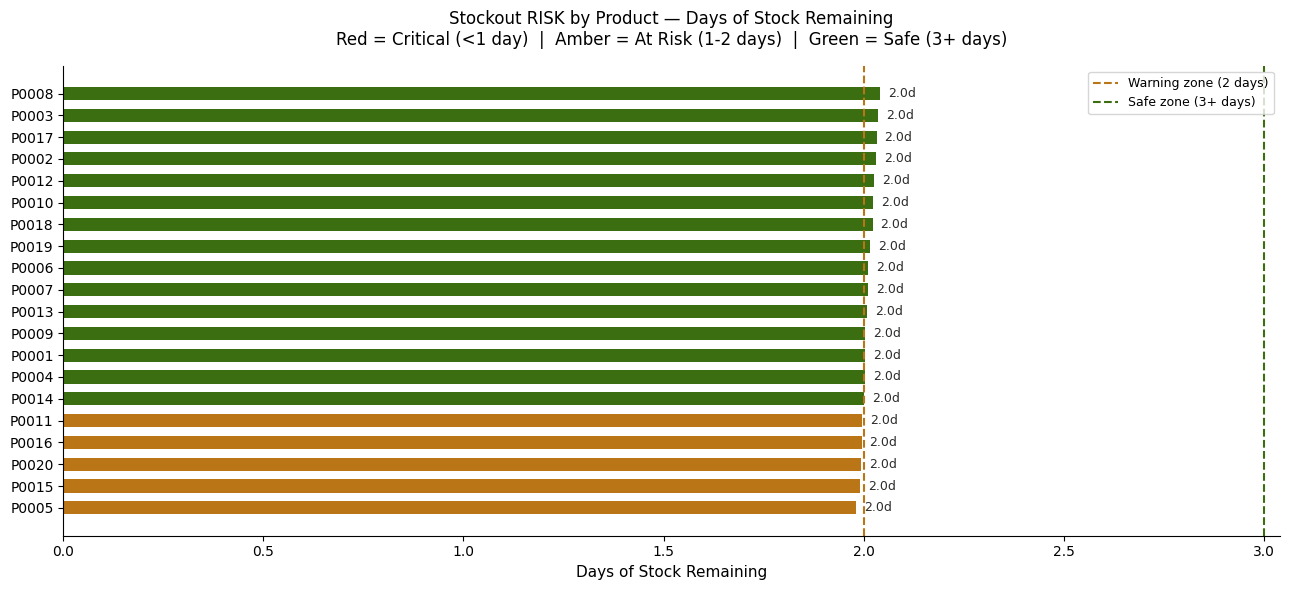

✅ Chart 1 saved


In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

# df already has cleaned column names from Cell 2 (lowercase + underscores)
risk_df = df.groupby('product_id').agg(
    category=('category', 'first'),
    avg_stock=('inventory_level', 'mean'),
    avg_daily_demand=('units_sold', 'mean')
).reset_index()

risk_df['days_of_stock'] = risk_df['avg_stock'] / risk_df['avg_daily_demand']
risk_df = risk_df.sort_values('days_of_stock')

colors_bar = ['#A32D2D' if x < 1 else '#BA7517' if x < 2 else '#3B6D11'
              for x in risk_df['days_of_stock']]

bars = ax.barh(risk_df['product_id'], risk_df['days_of_stock'],
               color=colors_bar, edgecolor='none', height=0.6)

ax.axvline(x=2, color='#BA7517', linestyle='--', linewidth=1.5, label='Warning zone (2 days)')
ax.axvline(x=3, color='#3B6D11', linestyle='--', linewidth=1.5, label='Safe zone (3+ days)')

for bar, val in zip(bars, risk_df['days_of_stock']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}d', va='center', fontsize=9, color='#2C2C2A')

ax.set_xlabel('Days of Stock Remaining', fontsize=11)
ax.set_title('Stockout RISK by Product — Days of Stock Remaining\n'
             'Red = Critical (<1 day)  |  Amber = At Risk (1-2 days)  |  Green = Safe (3+ days)',
             fontsize=12, pad=15)
ax.legend(fontsize=9)
ax.set_xlim(0, risk_df['days_of_stock'].max() + 1)
plt.tight_layout()
plt.savefig('../data/output/chart1_stockout_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

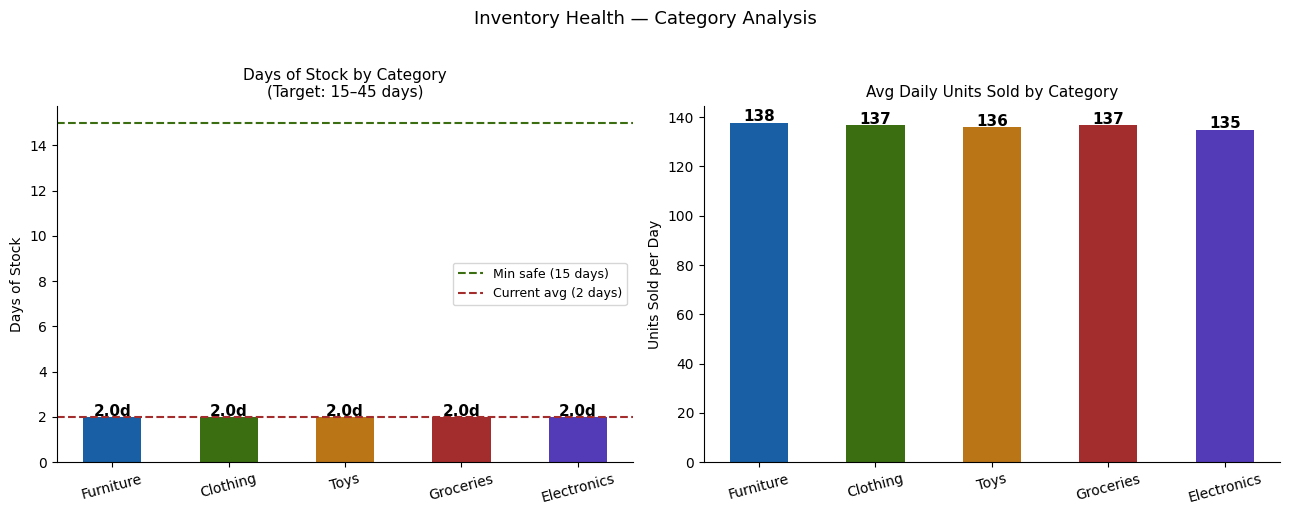

✅ Chart 2 saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_cat = ['#185FA5', '#3B6D11', '#BA7517', '#A32D2D', '#533AB7']

axes[0].bar(df_turnover['category'], df_turnover['days_of_stock'],
            color=colors_cat, edgecolor='none', width=0.5)
axes[0].axhline(y=15, color='#3B6D11', linestyle='--', linewidth=1.5, label='Min safe (15 days)')
axes[0].axhline(y=2,  color='#A32D2D', linestyle='--', linewidth=1.5, label='Current avg (2 days)')
for i, (cat, val) in enumerate(zip(df_turnover['category'], df_turnover['days_of_stock'])):
    axes[0].text(i, val + 0.05, f'{val:.1f}d', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Days of Stock by Category\n(Target: 15–45 days)', fontsize=11)
axes[0].set_ylabel('Days of Stock')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(df_turnover['category'], df_turnover['avg_daily_units_sold'],
            color=colors_cat, edgecolor='none', width=0.5)
for i, (cat, val) in enumerate(zip(df_turnover['category'], df_turnover['avg_daily_units_sold'])):
    axes[1].text(i, val + 0.5, f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Avg Daily Units Sold by Category', fontsize=11)
axes[1].set_ylabel('Units Sold per Day')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Inventory Health — Category Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/output/chart2_inventory_health.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

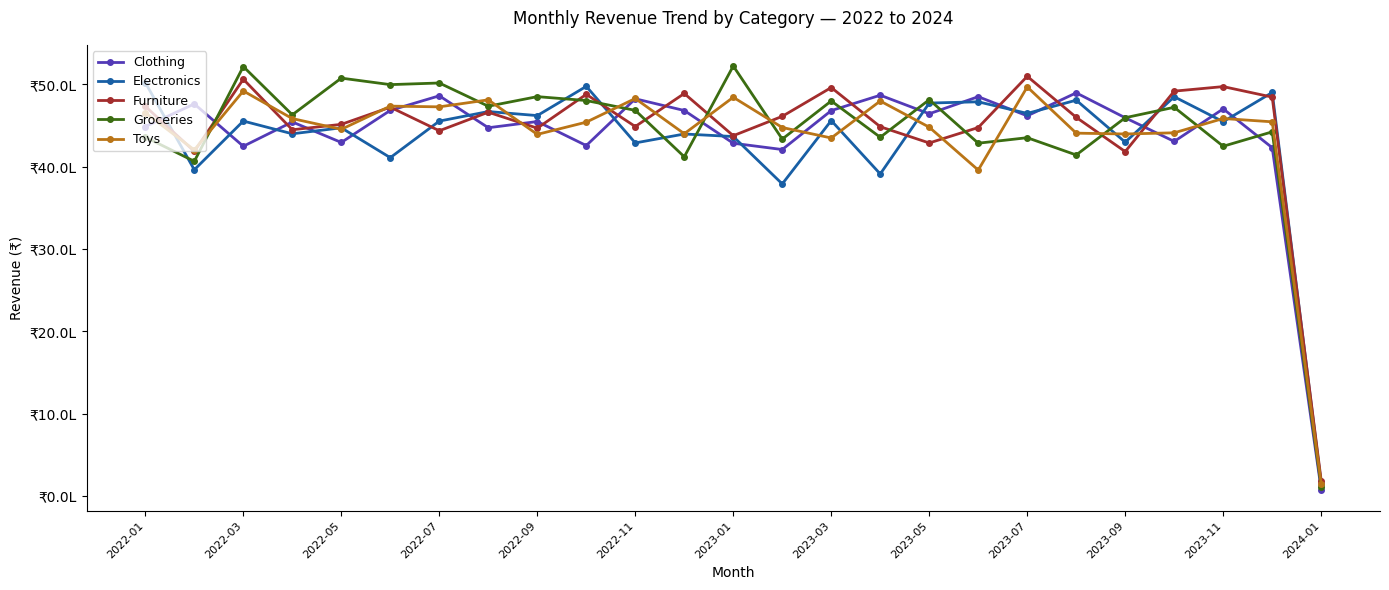

✅ Chart 3 saved


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

cat_colors = {
    'Electronics': '#185FA5',
    'Groceries':   '#3B6D11',
    'Clothing':    '#533AB7',
    'Toys':        '#BA7517',
    'Furniture':   '#A32D2D'
}

for cat in df_trend['category'].unique():
    data = df_trend[df_trend['category'] == cat].copy().reset_index(drop=True)
    ax.plot(range(len(data)), data['total_revenue'],
            marker='o', markersize=4, linewidth=2,
            label=cat, color=cat_colors.get(cat, '#444441'))

ax.set_title('Monthly Revenue Trend by Category — 2022 to 2024', fontsize=12, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L'))
ax.legend(loc='upper left', fontsize=9)

months_per_cat = len(df_trend[df_trend['category']=='Clothing'])
step = max(1, months_per_cat // 10)
tick_labels = df_trend[df_trend['category']=='Clothing']['month'].iloc[::step].tolist()
ax.set_xticks(range(0, months_per_cat, step))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../data/output/chart3_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

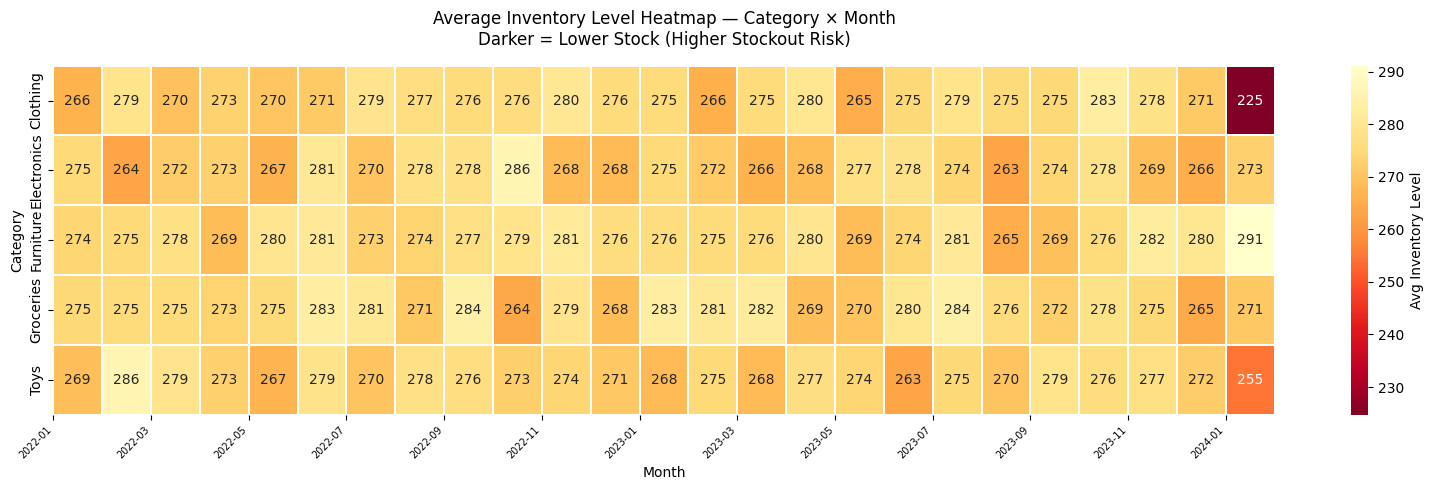

✅ Chart 4 saved


In [11]:
pivot = df_trend.pivot_table(
    index='category', columns='month',
    values='avg_inventory', aggfunc='mean'
).fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd_r', ax=ax, linewidths=0.3,
            linecolor='white', annot=True, fmt='.0f',
            cbar_kws={'label': 'Avg Inventory Level'})

ax.set_title('Average Inventory Level Heatmap — Category × Month\n'
             'Darker = Lower Stock (Higher Stockout Risk)', fontsize=12, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Category')

step = max(1, pivot.shape[1] // 12)
ax.set_xticks(range(0, pivot.shape[1], step))
ax.set_xticklabels([str(pivot.columns[i]) for i in range(0, pivot.shape[1], step)],
                   rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('../data/output/chart4_inventory_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

In [12]:
abc = df.groupby('product_id').agg(
    category=('category', 'first'),
    total_revenue=('units_sold', lambda x: (x * df.loc[x.index, 'price']).sum()),
    total_units=('units_sold', 'sum'),
    avg_inventory=('inventory_level', 'mean')
).reset_index()

abc = abc.sort_values('total_revenue', ascending=False).reset_index(drop=True)
abc['cumulative_pct'] = abc['total_revenue'].cumsum() / abc['total_revenue'].sum() * 100

abc['abc_class'] = abc['cumulative_pct'].apply(
    lambda x: 'A' if x <= 80 else ('B' if x <= 95 else 'C')
)

print("ABC CLASSIFICATION RESULTS")
print("=" * 60)
print(abc[['product_id', 'category', 'total_revenue', 'cumulative_pct', 'abc_class']].to_string(index=False))

print("\n\nSUMMARY:")
summary = abc.groupby('abc_class').agg(
    products=('product_id', 'count'),
    total_revenue=('total_revenue', 'sum')
).reset_index()
summary['revenue_pct'] = (summary['total_revenue'] / summary['total_revenue'].sum() * 100).round(1)
print(summary.to_string(index=False))

abc.to_csv('../data/output/abc_classification.csv', index=False)
print("\n✅ ABC classification saved")

ABC CLASSIFICATION RESULTS
product_id    category  total_revenue  cumulative_pct abc_class
     P0020        Toys    28306192.40            5.14         A
     P0011   Furniture    28155025.56           10.26         A
     P0016 Electronics    28153328.38           15.38         A
     P0014    Clothing    28110375.77           20.49         A
     P0005 Electronics    27916663.02           25.56         A
     P0013        Toys    27914863.65           30.63         A
     P0015    Clothing    27742249.64           35.68         A
     P0009 Electronics    27675549.22           40.71         A
     P0007   Furniture    27632505.00           45.73         A
     P0001   Groceries    27477692.24           50.72         A
     P0004        Toys    27477122.68           55.72         A
     P0018    Clothing    27287304.88           60.67         A
     P0010        Toys    27248852.75           65.63         A
     P0006   Groceries    27215738.62           70.57         A
     P0019   

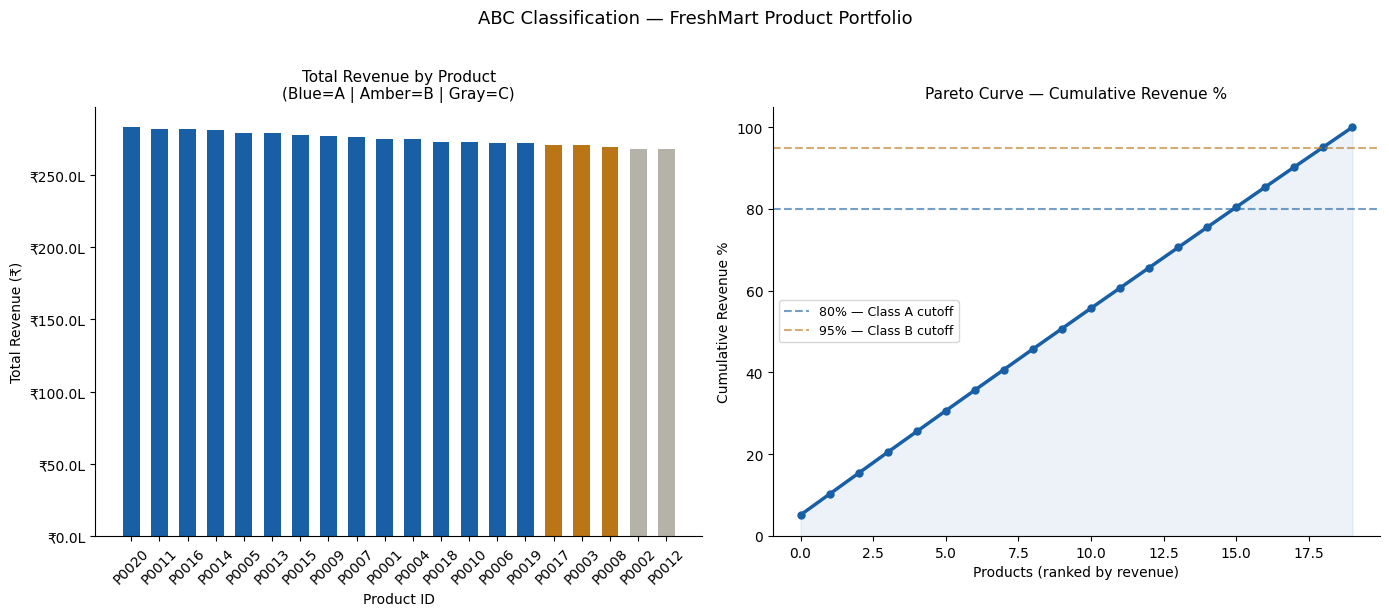

✅ Chart 5 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

abc_colors = {'A': '#185FA5', 'B': '#BA7517', 'C': '#B4B2A9'}
bar_colors = [abc_colors[c] for c in abc['abc_class']]

axes[0].bar(abc['product_id'], abc['total_revenue'],
            color=bar_colors, edgecolor='none', width=0.6)
axes[0].set_title('Total Revenue by Product\n(Blue=A | Amber=B | Gray=C)', fontsize=11)
axes[0].set_xlabel('Product ID')
axes[0].set_ylabel('Total Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(range(len(abc)), abc['cumulative_pct'],
             color='#185FA5', linewidth=2.5, marker='o', markersize=5)
axes[1].axhline(y=80, color='#185FA5', linestyle='--', alpha=0.6, label='80% — Class A cutoff')
axes[1].axhline(y=95, color='#BA7517', linestyle='--', alpha=0.6, label='95% — Class B cutoff')
axes[1].fill_between(range(len(abc)), abc['cumulative_pct'], alpha=0.08, color='#185FA5')
axes[1].set_title('Pareto Curve — Cumulative Revenue %', fontsize=11)
axes[1].set_xlabel('Products (ranked by revenue)')
axes[1].set_ylabel('Cumulative Revenue %')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.suptitle('ABC Classification — FreshMart Product Portfolio', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/output/chart5_abc_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")